# Dating Historical Color Images -- Using PyTorch Dataset Loading Utilities for Custom Datasets

## Libraries

In [33]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import scipy.io as sio
import imageio

## Downloading and Extracting the Dataset

The following bash commands (executed in this Jupyter notebook) will download and extract the dataset.

In [34]:
!curl http://graphics.cs.cmu.edu/projects/historicalColor/HistoricalColor-ECCV2012-DecadeDatabase.tar > HistoricalColor-ECCV2012-DecadeDatabase.tar

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  211M  100  211M    0     0  15.0M      0  0:00:14  0:00:14 --:--:-- 19.4M


In [35]:
!tar -xf  HistoricalColor-ECCV2012-DecadeDatabase.tar

## Investigating the Dataset

In [36]:
from pathlib import Path

all_jpg_paths = [filename for filename
                 in Path('HistoricalColor-ECCV2012').glob('**/**/*.jpg')]
print(f'Number of jpgs: {len(all_jpg_paths)}')

Number of jpgs: 1326


Let's have a look at a few example files:

/tmp/ipykernel_36/3397321595.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread(all_jpg_paths[0])


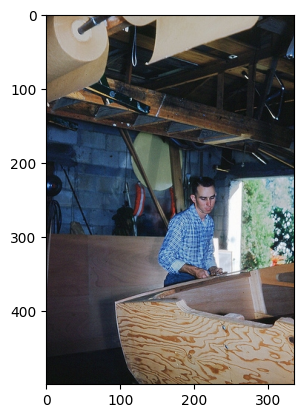

In [37]:
im = imageio.imread(all_jpg_paths[0])
plt.imshow(im);

/tmp/ipykernel_36/273197366.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread(all_jpg_paths[-1])


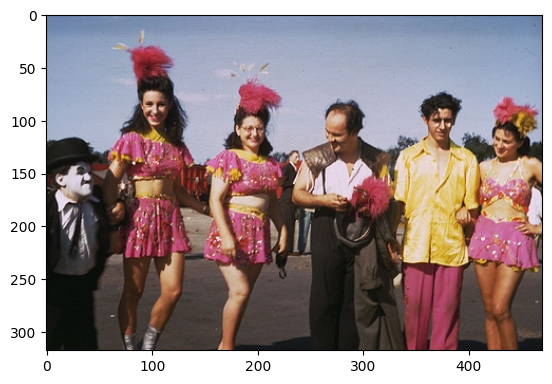

In [38]:
im = imageio.imread(all_jpg_paths[-1])
plt.imshow(im);

In [ ]:
print(f'Min height: {min(all_heights)}')
print(f'Min width: {min(all_widths)}')

## Creating Label Files

In [40]:
os.path.basename(os.path.dirname(all_jpg_paths[0]))

'1950s'

In [41]:
class_label_mapping = {'1930s': 0,
                       '1940s': 1,
                       '1950s': 2,
                       '1960s': 3,
                       '1970s': 4}

df = pd.DataFrame(all_jpg_paths, columns=['paths'])
df['year'] = df['paths'].apply(lambda x: os.path.basename(os.path.dirname(x)))
df['labels'] = df['year'].map(class_label_mapping)
df.head()

,paths,year,labels
0,HistoricalColor-ECCV2012/data/imgs/decade_data...,1950s,2
1,HistoricalColor-ECCV2012/data/imgs/decade_data...,1950s,2
2,HistoricalColor-ECCV2012/data/imgs/decade_data...,1950s,2
3,HistoricalColor-ECCV2012/data/imgs/decade_data...,1950s,2
4,HistoricalColor-ECCV2012/data/imgs/decade_data...,1950s,2


Next, we are doing a stratified split that divides the dataset into 80% training data and 20% test data while preserving the class propotions.

In [42]:
from sklearn.model_selection import train_test_split

df_train, df_test = \
        train_test_split(df, 
                         stratify=df['labels'].values, 
                         random_state=123, 
                         test_size=0.2)

Finally, we are going to save the dataset partitioning to disk:

In [43]:
df_train.to_csv('HistoricalColor-train.csv', index=False)
df_test.to_csv('HistoricalColor-test.csv', index=False)

## Implementing a Custom Dataset Class

In [44]:
class HistoricalColorDataset(Dataset):
    """Custom Dataset for the HistoricalColor images"""
    
    def __init__(self, csv_path, root_dir, transform=None):
    
        df = pd.read_csv(csv_path, index_col='paths')
        self.root_dir = root_dir
        self.csv_path = csv_path
        self.img_paths = df.index.values
        
        self.y = df['labels'].values
        self.transform = transform

    def __getitem__(self, index):
        img = Image.open(os.path.join(self.root_dir,
                                      self.img_paths[index]))
        
        if self.transform is not None:
            img = self.transform(img)
        
        label = self.y[index]
        return img, label

    def __len__(self):
        return self.y.shape[0]

In [45]:
custom_transform_train = transforms.Compose([transforms.RandomCrop((312, 312)), transforms.ToTensor()])

custom_transform_test = transforms.Compose([transforms.CenterCrop((312, 312)), transforms.ToTensor()])

train_dataset = HistoricalColorDataset(csv_path='HistoricalColor-train.csv',
                                       root_dir='.',
                                       transform=custom_transform_train)

test_dataset = HistoricalColorDataset(csv_path='HistoricalColor-test.csv',
                                      root_dir='.',
                                      transform=custom_transform_test)

BATCH_SIZE=128

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=4)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=4)

## Iterating Through the Custom Dataset

In [46]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

num_epochs = 2
for epoch in range(num_epochs):

    for batch_idx, (x, y) in enumerate(train_loader):
        
        print('Epoch:', epoch+1, end='')
        print(' | Batch index:', batch_idx, end='')
        print(' | Batch size:', y.size()[0])
        
        x = x.to(device)
        y = y.to(device)
        break

Epoch: 1 | Batch index: 0 | Batch size: 128
Epoch: 2 | Batch index: 0 | Batch size: 128


Just to make sure that the batches are being loaded correctly, let's print out the dimensions of the last batch:

In [47]:
x.shape

torch.Size([128, 3, 312, 312])

In [48]:
one_image = x[0].permute(1, 2, 0)
one_image.shape

torch.Size([312, 312, 3])

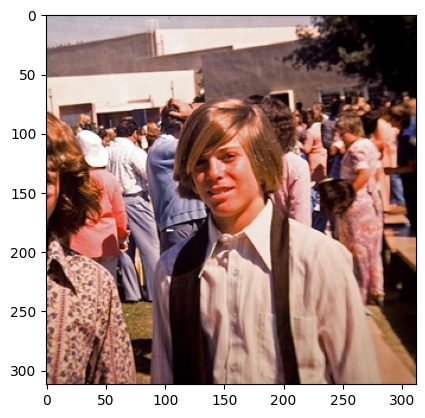

In [49]:
plt.imshow(one_image.to(torch.device('cpu')));